# Import Libraries

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Linear Regression Class Implementation

In [15]:
class SimpleLinearRegression:
    def __init__(self):
        self.coefficient = None
        self.intercept = None
        self.r2score = None
    
    def fit(self, X, y):
        n = len(X)
        # Add bias term
        X_b = np.c_[np.ones((n,1)), X]
        
        # Calculate coefficients using normal equation
        self.coefficient = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
        self.intercept = self.coefficient[0]
        y_pred = X_b @ self.coefficient
        
        # Calculate R-squared score
        self.r2score = 1 - (np.sum((y - y_pred) ** 2) / np.sum((y - np.mean(y)) ** 2))
        self.y_pred = y_pred
    
    def predict(self, X):
        # Add bias term
        n = len(X)
        X_b = np.c_[np.ones((n,1)), X]
        # Predict using the learned coefficients
        return X_b @ self.coefficient

# Fit the Model

In [16]:
X_train = np.array([1, 2, 3, 4, 5]).reshape(-1,1)
y_train = np.array([2, 3, 5, 7, 11])

slr = SimpleLinearRegression()
slr.fit(X_train, y_train)

print(f"Coefficient: {slr.coefficient}")
print(f"Intercept: {slr.intercept}")
print(f"R-squared Score: {slr.r2score}")

# Make Predictions
X_test = np.array([6, 7, 8, 9, 10]).reshape(-1,1)
y_test = np.array([13, 17, 21, 25, 29])

Coefficient: [-1.   2.2]
Intercept: -0.9999999999999958
R-squared Score: 0.9453125


# Visualize Results

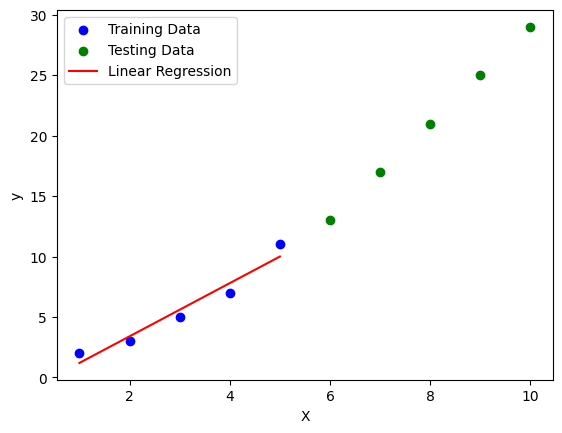

In [17]:
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.scatter(X_test, y_test, color='green', label='Testing Data')
plt.plot(X_train, slr.predict(X_train), color='red', label='Linear Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

# MultipleLinearRegression class Implementation

In [18]:
class MultipleLinearRegression:
    def __init__(self):
        self.coefficients = None
        self.intercept = None
        self.r2score = None
    
    def fit(self, X, y):
        n = len(X)
        X_b = np.c_[np.ones((n,1)), X]
        
        # Calculate coefficients using normal equation
        self.coefficients = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
        self.intercept = self.coefficients[0]
        y_pred = X_b @ self.coefficients
        
        # Calculate R-squared score
        self.r2score = 1 - (np.sum((y - y_pred) ** 2) / np.sum((y - np.mean(y)) ** 2))
        self.y_pred = y_pred
    
    def predict(self, X):
        n = len(X)
        X_b = np.c_[np.ones((n,1)), X]
        return X_b @ self.coefficients


# Generate Sample Dataset

In [19]:
np.random.seed(42)
X = np.random.rand(100, 3)
y = 2 * X[:, 0] + 3 * X[:, 1] + 4 * X[:, 2] + np.random.randn(100)

# Fit the Model

In [20]:
mlr = MultipleLinearRegression()
mlr.fit(X, y)

print(f"Coefficients: {mlr.coefficients}")
print(f"Intercept: {mlr.intercept}")
print(f"R-squared Score: {mlr.r2score}")

# Make Predictions
X_test = np.random.rand(10, 3)
y_pred = mlr.predict(X_test)

Coefficients: [-0.26498544  2.27800411  2.84223781  4.57040576]
Intercept: -0.2649854448422603
R-squared Score: 0.7513523057786622


# Visualize

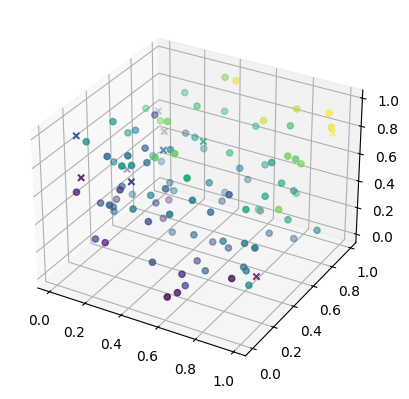

In [21]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='viridis')
ax.scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2], c=y_pred, cmap='viridis', marker='x')
plt.show()